# 01. EDA - 스마트 창고 출고 지연 예측

## 대회 정보
- **주제**: 향후 30분간 평균 출고 지연 시간(분) 예측
- **평가지표**: MAE
- **타겟**: `avg_delay_minutes_next_30m`
- **피처**: 90개 원본 + layout 14개 = 104개 활용 가능

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

TARGET = 'avg_delay_minutes_next_30m'   # 타겟 컬럼명 (전역 상수)

print('Libraries loaded!')

Libraries loaded!


## 1. 데이터 로드

In [2]:
DATA_PATH = '../data/'

train = pd.read_csv(DATA_PATH + 'train.csv')
test = pd.read_csv(DATA_PATH + 'test.csv')
layout = pd.read_csv(DATA_PATH + 'layout_info.csv')
submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Layout shape: {layout.shape}')
print(f'Submission shape: {submission.shape}')

Train shape: (250000, 94)
Test shape: (50000, 93)
Layout shape: (300, 15)
Submission shape: (50000, 2)


## 2. 기본 정보 확인

In [3]:
print('=== Train Info ===')
print(train.info())
print('\n=== Train Describe ===')
train.describe()

=== Train Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 94 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          250000 non-null  object 
 1   layout_id                   250000 non-null  object 
 2   scenario_id                 250000 non-null  object 
 3   order_inflow_15m            220436 non-null  float64
 4   unique_sku_15m              220076 non-null  float64
 5   avg_items_per_order         220377 non-null  float64
 6   urgent_order_ratio          220246 non-null  float64
 7   heavy_item_ratio            220384 non-null  float64
 8   cold_chain_ratio            220549 non-null  float64
 9   sku_concentration           220301 non-null  float64
 10  robot_active                250000 non-null  int64  
 11  robot_idle                  250000 non-null  int64  
 12  robot_charging              250000 non-null  int64  


,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,robot_active,robot_idle,robot_charging,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
count,220436.000000,220076.000000,220377.000000,220246.000000,220384.000000,220549.000000,220301.000000,250000.000000,250000.000000,250000.000000,...,220358.000000,220457.000000,220273.000000,220448.000000,220544.000000,220532.000000,220595.000000,220448.000000,220466.000000,220230.000000
mean,94.585662,108.275673,3.473318,0.112411,0.179021,0.094962,0.425110,13.379388,25.813408,6.128704,...,6.895087,0.214840,4.927512,0.126086,14.018698,9.291452,87.077735,0.092604,5.005130,96.429794
std,77.083546,105.558290,2.190259,0.108145,0.111210,0.081449,0.192997,11.449100,22.687023,12.433735,...,2.246697,0.106773,2.213228,0.059362,7.103918,4.791728,6.328054,0.041663,3.034295,2.127183
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.500000,0.000000,0.000000,1.000000,70.000000,0.000000,0.000000,90.000000
25%,29.000000,37.000000,1.460000,0.023300,0.100000,0.026000,0.268500,4.000000,2.000000,0.000000,...,5.080000,0.130400,3.260000,0.079200,8.600000,5.430000,82.300000,0.060600,2.510000,94.770000
50%,78.000000,73.000000,2.840000,0.081100,0.176500,0.083300,0.399300,10.000000,23.000000,0.000000,...,6.890000,0.214600,4.910000,0.126300,13.900000,9.300000,87.100000,0.092200,5.020000,96.450000
75%,142.000000,141.000000,4.980000,0.179900,0.254600,0.144400,0.557000,19.000000,45.000000,6.000000,...,8.710000,0.298800,6.450000,0.172700,18.800000,13.080000,91.900000,0.124000,7.470000,98.150000
max,477.000000,500.000000,15.000000,1.000000,1.000000,0.500000,0.900000,79.000000,80.000000,80.000000,...,12.000000,0.500000,10.000000,0.300000,30.000000,24.000000,100.000000,0.200000,15.000000,100.000000


In [4]:
print('=== Train Head ===')
train.head()

=== Train Head ===


,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02


In [5]:
print('=== Test Head ===')
test.head()

=== Test Head ===


,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TEST_000000,WH_202,SC_10973,61.0,155.0,NaN,0.0000,0.0656,0.1311,0.3047,...,4.88,0.0534,4.93,0.2164,13.5,NaN,96.2,0.0374,0.00,97.74
1,TEST_000001,WH_202,SC_10973,59.0,108.0,NaN,NaN,0.0847,0.0847,0.3047,...,6.69,NaN,NaN,NaN,21.1,15.94,90.5,0.0522,3.03,NaN
2,TEST_000002,WH_202,SC_10973,95.0,200.0,3.35,0.0526,NaN,0.1053,0.3047,...,6.28,0.0534,8.57,0.2292,23.2,16.25,NaN,0.0649,1.36,95.31
3,TEST_000003,WH_202,SC_10973,59.0,166.0,4.20,0.0339,0.0508,0.1017,0.3047,...,7.92,0.0835,NaN,0.2045,NaN,15.57,NaN,0.0268,0.64,94.01
4,TEST_000004,WH_202,SC_10973,NaN,130.0,NaN,0.0200,0.0200,0.1000,0.3047,...,7.00,0.1684,NaN,0.2174,NaN,17.16,91.0,0.0533,0.25,95.66


In [6]:
print('=== Layout Info ===')
print(layout.info())
print('\n')
layout.head()

=== Layout Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   layout_id             300 non-null    object 
 1   layout_type           300 non-null    object 
 2   aisle_width_avg       300 non-null    float64
 3   intersection_count    300 non-null    float64
 4   one_way_ratio         300 non-null    float64
 5   pack_station_count    300 non-null    float64
 6   charger_count         300 non-null    float64
 7   layout_compactness    300 non-null    float64
 8   zone_dispersion       300 non-null    float64
 9   robot_total           300 non-null    int64  
 10  building_age_years    300 non-null    int64  
 11  floor_area_sqm        300 non-null    int64  
 12  ceiling_height_m      300 non-null    float64
 13  fire_sprinkler_count  300 non-null    int64  
 14  emergency_exit_count  300 non-null    int64  
dtypes: 

,layout_id,layout_type,aisle_width_avg,intersection_count,one_way_ratio,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,WH_001,narrow,2.08,34.0,0.3874,9.0,8.0,0.8078,0.5867,21,20,3384,9.4,36,5
1,WH_002,grid,3.70,16.0,0.0054,9.0,11.0,0.7339,0.4390,57,26,8311,8.1,12,2
2,WH_003,grid,2.54,52.0,0.0229,5.0,3.0,0.5498,0.3708,63,39,9465,7.2,81,2
3,WH_004,hybrid,3.37,35.0,0.4836,5.0,10.0,0.4821,0.5661,100,40,7918,12.7,26,5
4,WH_005,grid,3.68,48.0,0.0494,8.0,13.0,0.6740,0.9970,50,33,5905,5.6,84,9


## 3. 결측치 분석

In [7]:
# 결측치 비율 확인
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

if len(missing_train) > 0:
    print(f'결측치가 있는 컬럼 수: {len(missing_train)}')
    print('\n결측치 비율 (%):')
    print((missing_train / len(train) * 100).round(2))
else:
    print('결측치 없음!')

결측치가 있는 컬럼 수: 86

결측치 비율 (%):
avg_recovery_time        13.01
congestion_score         12.90
avg_charge_wait          12.28
battery_mean             12.13
charge_efficiency_pct    12.02
                         ...  
near_collision_15m       11.76
battery_std              11.75
aisle_traffic_score      11.74
task_reassign_15m        11.73
air_quality_idx          11.73
Length: 86, dtype: float64


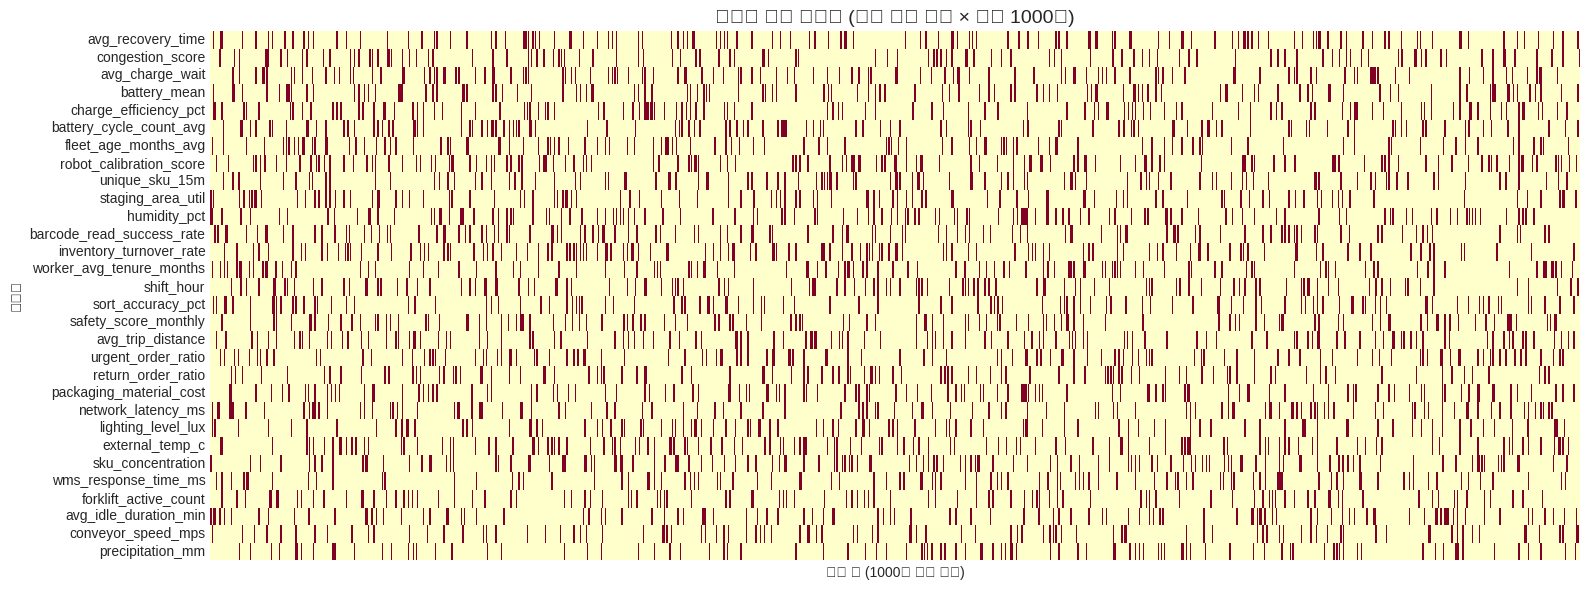

결측치 있는 컬럼 수: 86
평균 결측치 비율: 11.9%


In [8]:
# 결측치 히트맵 (상위 30개 컬럼)
import seaborn as sns

missing_pct = train.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
top_missing_cols = missing_pct.head(30).index.tolist()

if len(top_missing_cols) > 0:
    fig, ax = plt.subplots(figsize=(16, 6))
    missing_matrix = train[top_missing_cols].isnull().astype(int).T
    # 랜덤 샘플 1000행으로 히트맵
    sample_idx = np.random.RandomState(42).choice(len(train), size=min(1000, len(train)), replace=False)
    missing_sample = missing_matrix.iloc[:, sample_idx]
    sns.heatmap(missing_sample, cbar=False, yticklabels=True, xticklabels=False,
                cmap='YlOrRd', ax=ax)
    ax.set_title('결측치 패턴 히트맵 (상위 결측 컬럼 × 샘플 1000행)', fontsize=14)
    ax.set_xlabel('샘플 행 (1000개 랜덤 샘플)')
    ax.set_ylabel('컬럼명')
    plt.tight_layout()
    plt.savefig('../docs/missing_value_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'결측치 있는 컬럼 수: {len(missing_pct)}')
    print(f'평균 결측치 비율: {missing_pct.mean():.1f}%')
else:
    print('결측치 없음')


## 4. 타겟 변수 분석 (`avg_delay_minutes_next_30m`)

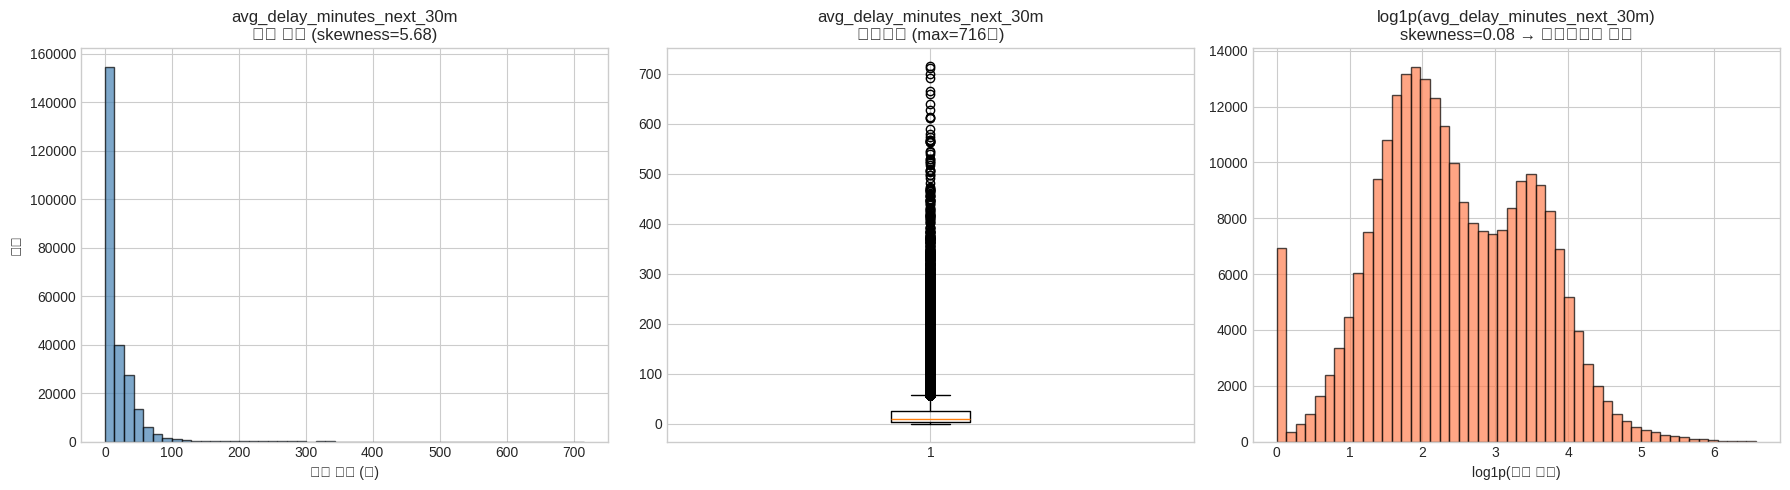

=== 타겟 통계 ===
count    250000.00
mean         18.96
std          27.35
min           0.00
25%           4.28
50%           9.03
75%          25.79
max         715.86
Name: avg_delay_minutes_next_30m, dtype: float64

0분 비율: 2.7%
원본 skewness: 5.682
log1p skewness: 0.080  → ✅ 로그 변환 권장


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 원본 분포
axes[0].hist(train[TARGET], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title(f'{TARGET}\n원본 분포 (skewness={train[TARGET].skew():.2f})')
axes[0].set_xlabel('지연 시간 (분)')
axes[0].set_ylabel('빈도')

# 박스플롯
axes[1].boxplot(train[TARGET], vert=True)
axes[1].set_title(f'{TARGET}\n박스플롯 (max={train[TARGET].max():.0f}분)')

# log1p 변환 분포
log_target = np.log1p(train[TARGET])
axes[2].hist(log_target, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[2].set_title(f'log1p({TARGET})\nskewness={log_target.skew():.2f} → 정규분포에 근접')
axes[2].set_xlabel('log1p(지연 시간)')

plt.tight_layout()
plt.savefig('../docs/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'=== 타겟 통계 ===')
print(train[TARGET].describe().round(2))
print(f'\n0분 비율: {(train[TARGET] == 0).mean()*100:.1f}%')
print(f'원본 skewness: {train[TARGET].skew():.3f}')
print(f'log1p skewness: {log_target.skew():.3f}  → ✅ 로그 변환 권장')

## 5. 피처 분석

In [10]:
# 수치형 피처 목록
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

print(f'수치형 피처 수: {len(num_cols)}')
print(f'범주형 피처 수: {len(cat_cols)}')

if cat_cols:
    print(f'\n범주형 피처: {cat_cols}')

수치형 피처 수: 91
범주형 피처 수: 3

범주형 피처: ['ID', 'layout_id', 'scenario_id']


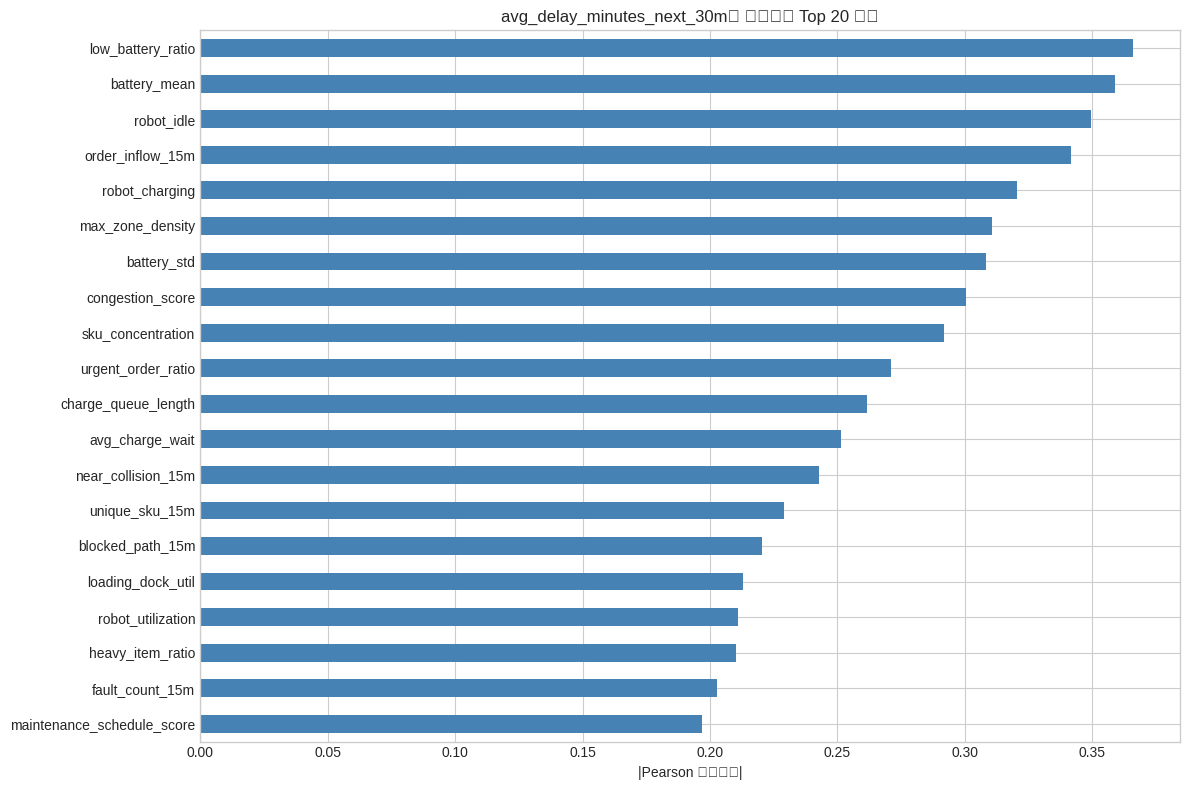

=== Top 15 상관 피처 ===
  low_battery_ratio                   0.366
  battery_mean                        0.359
  robot_idle                          0.349
  order_inflow_15m                    0.342
  robot_charging                      0.320
  max_zone_density                    0.311
  battery_std                         0.308
  congestion_score                    0.300
  sku_concentration                   0.292
  urgent_order_ratio                  0.271
  charge_queue_length                 0.261
  avg_charge_wait                     0.251
  near_collision_15m                  0.243
  unique_sku_15m                      0.229
  blocked_path_15m                    0.220


In [11]:
# 타겟과의 상관관계 Top 20
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = (
    train[num_cols].corr()[TARGET]
    .drop(TARGET).abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))
corr_with_target.head(20).plot(kind='barh', color='steelblue')
plt.title(f'{TARGET}와 상관관계 Top 20 피처')
plt.xlabel('|Pearson 상관계수|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/feature_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print('=== Top 15 상관 피처 ===')
for feat, val in corr_with_target.head(15).items():
    print(f'  {feat:<35s} {val:.3f}')

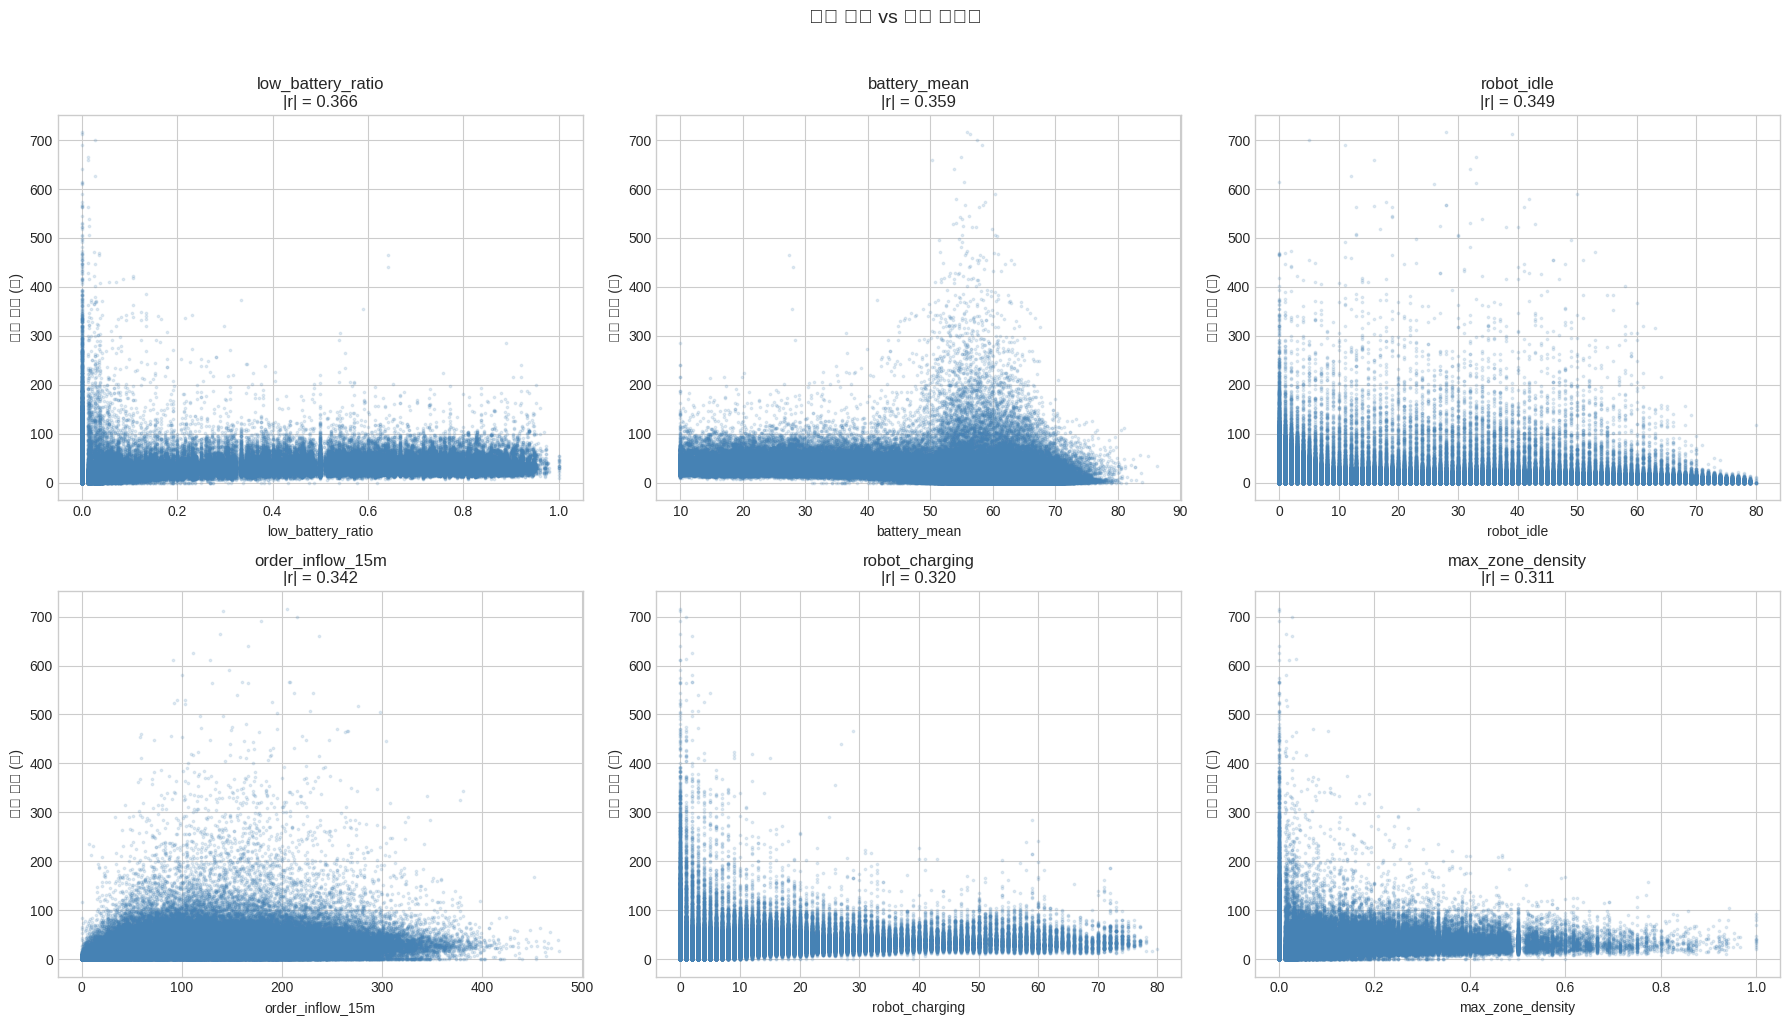

In [12]:
# 상위 6개 피처 산점도 (타겟 vs 피처)
top_features = corr_with_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, feat in enumerate(top_features):
    row, col = idx // 3, idx % 3
    axes[row][col].scatter(train[feat], train[TARGET], alpha=0.15, s=3, color='steelblue')
    axes[row][col].set_xlabel(feat)
    axes[row][col].set_ylabel('지연 시간 (분)')
    corr_val = corr_with_target[feat]
    axes[row][col].set_title(f'{feat}\n|r| = {corr_val:.3f}')

plt.suptitle('핵심 피처 vs 타겟 산점도', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. 시나리오/타임슬롯 분석

고유 시나리오 수 (train): 10000
고유 시나리오 수 (test) : 2000
시나리오당 타임슬롯 수  : [25] (균일)


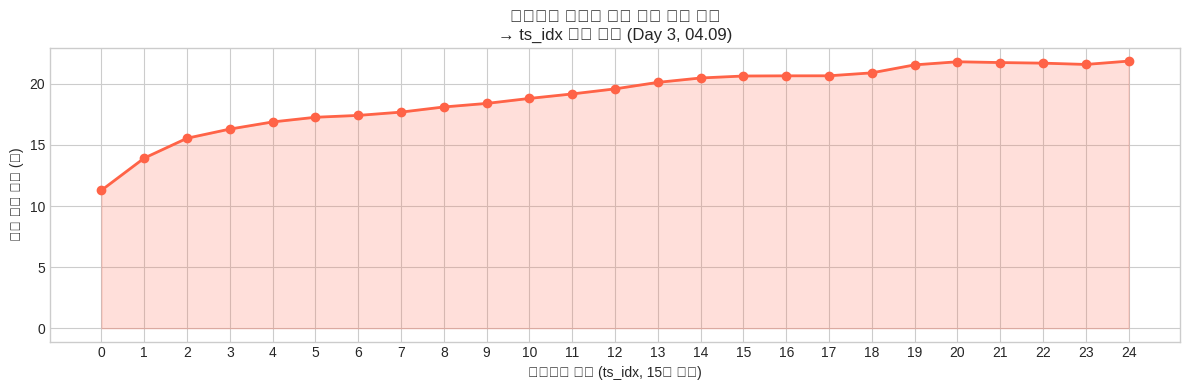


ts=0 평균: 11.29분  |  ts=24 평균: 21.86분
→ 시나리오 종료 시점에 지연이 1.9배 증가


In [13]:
# 시나리오 내 타임슬롯 순서 생성
train['ts_idx'] = train.groupby('scenario_id').cumcount()
test['ts_idx']  = test.groupby('scenario_id').cumcount()

print(f'고유 시나리오 수 (train): {train["scenario_id"].nunique()}')
print(f'고유 시나리오 수 (test) : {test["scenario_id"].nunique()}')
print(f'시나리오당 타임슬롯 수  : {train.groupby("scenario_id").size().unique()} (균일)')

# 타임슬롯 진행에 따른 평균 지연 변화
ts_mean = train.groupby('ts_idx')[TARGET].mean()

plt.figure(figsize=(12, 4))
plt.plot(ts_mean.index, ts_mean.values, marker='o', color='tomato', linewidth=2)
plt.fill_between(ts_mean.index, ts_mean.values, alpha=0.2, color='tomato')
plt.xlabel('타임슬롯 순서 (ts_idx, 15분 간격)')
plt.ylabel('평균 출고 지연 (분)')
plt.title('시나리오 진행에 따른 평균 지연 증가\n→ ts_idx 피처 필수 (Day 3, 04.09)')
plt.xticks(range(0, 25))
plt.tight_layout()
plt.savefig('../docs/timeslot_delay_pattern.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nts=0 평균: {ts_mean[0]:.2f}분  |  ts=24 평균: {ts_mean[24]:.2f}분')
print(f'→ 시나리오 종료 시점에 지연이 {ts_mean[24]/ts_mean[0]:.1f}배 증가')

## 7. Layout 보조 테이블 분석

In [14]:
print('=== Layout 컬럼 ===')
print(layout.columns.tolist())
print(f'\nLayout shape: {layout.shape}')
print('\n=== Layout Describe ===')
layout.describe()

=== Layout 컬럼 ===
['layout_id', 'layout_type', 'aisle_width_avg', 'intersection_count', 'one_way_ratio', 'pack_station_count', 'charger_count', 'layout_compactness', 'zone_dispersion', 'robot_total', 'building_age_years', 'floor_area_sqm', 'ceiling_height_m', 'fire_sprinkler_count', 'emergency_exit_count']

Layout shape: (300, 15)

=== Layout Describe ===


,aisle_width_avg,intersection_count,one_way_ratio,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2.807533,31.206667,0.251474,11.120000,8.590000,0.624137,0.545910,47.113333,27.643333,5464.840000,9.572667,54.700000,6.040000
std,0.664265,13.166186,0.177880,5.764521,4.462617,0.146548,0.271727,21.718336,12.978093,2690.543934,3.185658,25.964022,2.681237
min,1.500000,5.000000,0.001700,1.000000,1.000000,0.305700,0.101300,8.000000,5.000000,511.000000,4.000000,10.000000,2.000000
25%,2.260000,21.000000,0.119225,6.000000,5.000000,0.526425,0.313600,28.000000,17.000000,3237.250000,6.800000,31.750000,4.000000
50%,2.830000,30.000000,0.209650,11.000000,9.000000,0.611650,0.565750,46.500000,28.000000,5626.500000,9.900000,55.000000,6.000000
75%,3.370000,42.000000,0.357150,16.000000,13.000000,0.717575,0.797225,65.000000,38.000000,7800.000000,12.200000,78.000000,9.000000
max,4.000000,60.000000,0.792200,24.000000,18.000000,0.997700,0.998500,100.000000,50.000000,9967.000000,14.800000,100.000000,10.000000


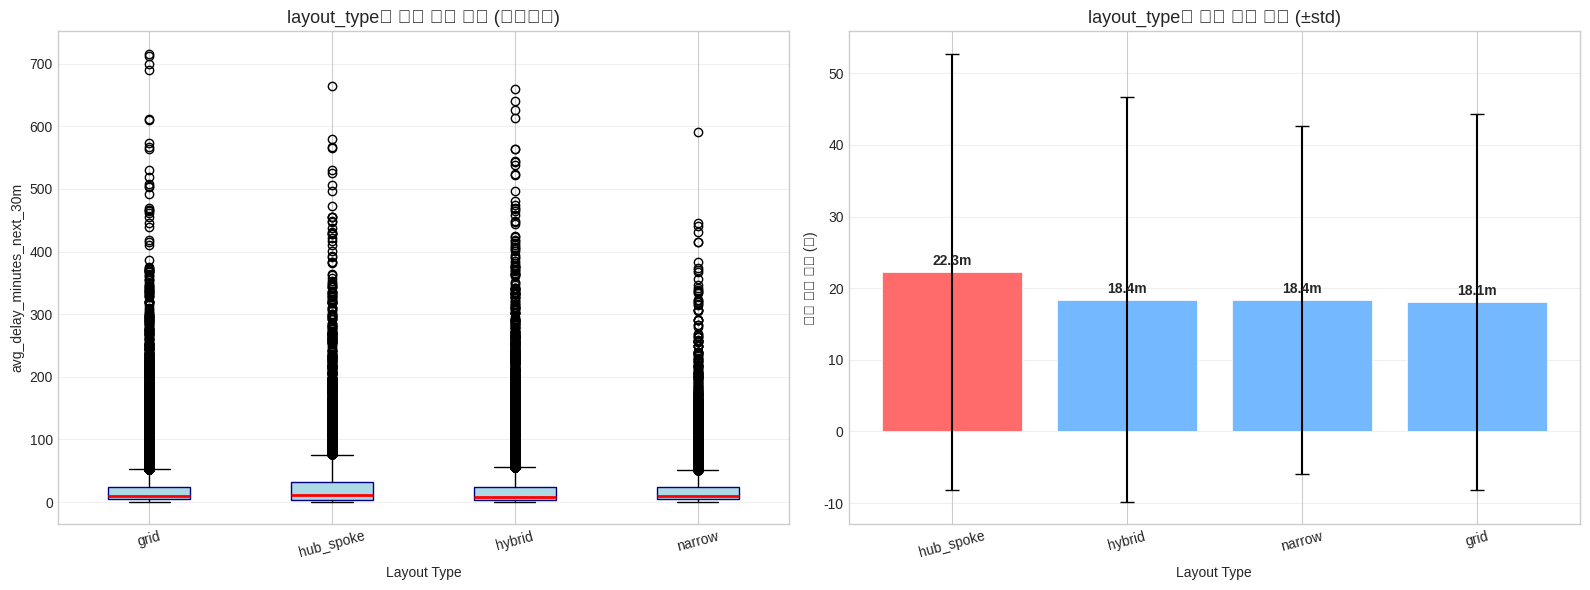


=== layout_type별 요약 통계 ===
              mean  median    std
layout_type                      
hub_spoke    22.28   11.32  30.44
hybrid       18.41    8.25  28.28
narrow       18.36    9.47  24.27
grid         18.10    8.92  26.25


In [15]:
# layout_type별 타겟 분포 박스플롯
TARGET = 'avg_delay_minutes_next_30m'

train_layout = train.merge(layout[['layout_id', 'layout_type']], on='layout_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 박스플롯
layout_types = sorted(train_layout['layout_type'].dropna().unique())
data_by_type = [train_layout[train_layout['layout_type'] == lt][TARGET].values for lt in layout_types]

axes[0].boxplot(data_by_type, labels=layout_types, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('layout_type별 출고 지연 분포 (박스플롯)', fontsize=13)
axes[0].set_xlabel('Layout Type')
axes[0].set_ylabel('avg_delay_minutes_next_30m')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# 평균 비교 바차트
mean_by_type = train_layout.groupby('layout_type')[TARGET].agg(['mean', 'median', 'std'])
mean_by_type = mean_by_type.sort_values('mean', ascending=False)
colors = ['#FF6B6B' if v == mean_by_type['mean'].max() else '#74B9FF' for v in mean_by_type['mean']]
bars = axes[1].bar(mean_by_type.index, mean_by_type['mean'], color=colors, edgecolor='white', linewidth=0.5)
axes[1].errorbar(range(len(mean_by_type)), mean_by_type['mean'], yerr=mean_by_type['std'],
                 fmt='none', color='black', capsize=5)
axes[1].set_title('layout_type별 평균 출고 지연 (±std)', fontsize=13)
axes[1].set_xlabel('Layout Type')
axes[1].set_ylabel('평균 지연 시간 (분)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, mean_by_type['mean']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}m', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/layout_type_delay_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== layout_type별 요약 통계 ===')
print(mean_by_type.round(2))


## 8. Train/Test 분포 비교

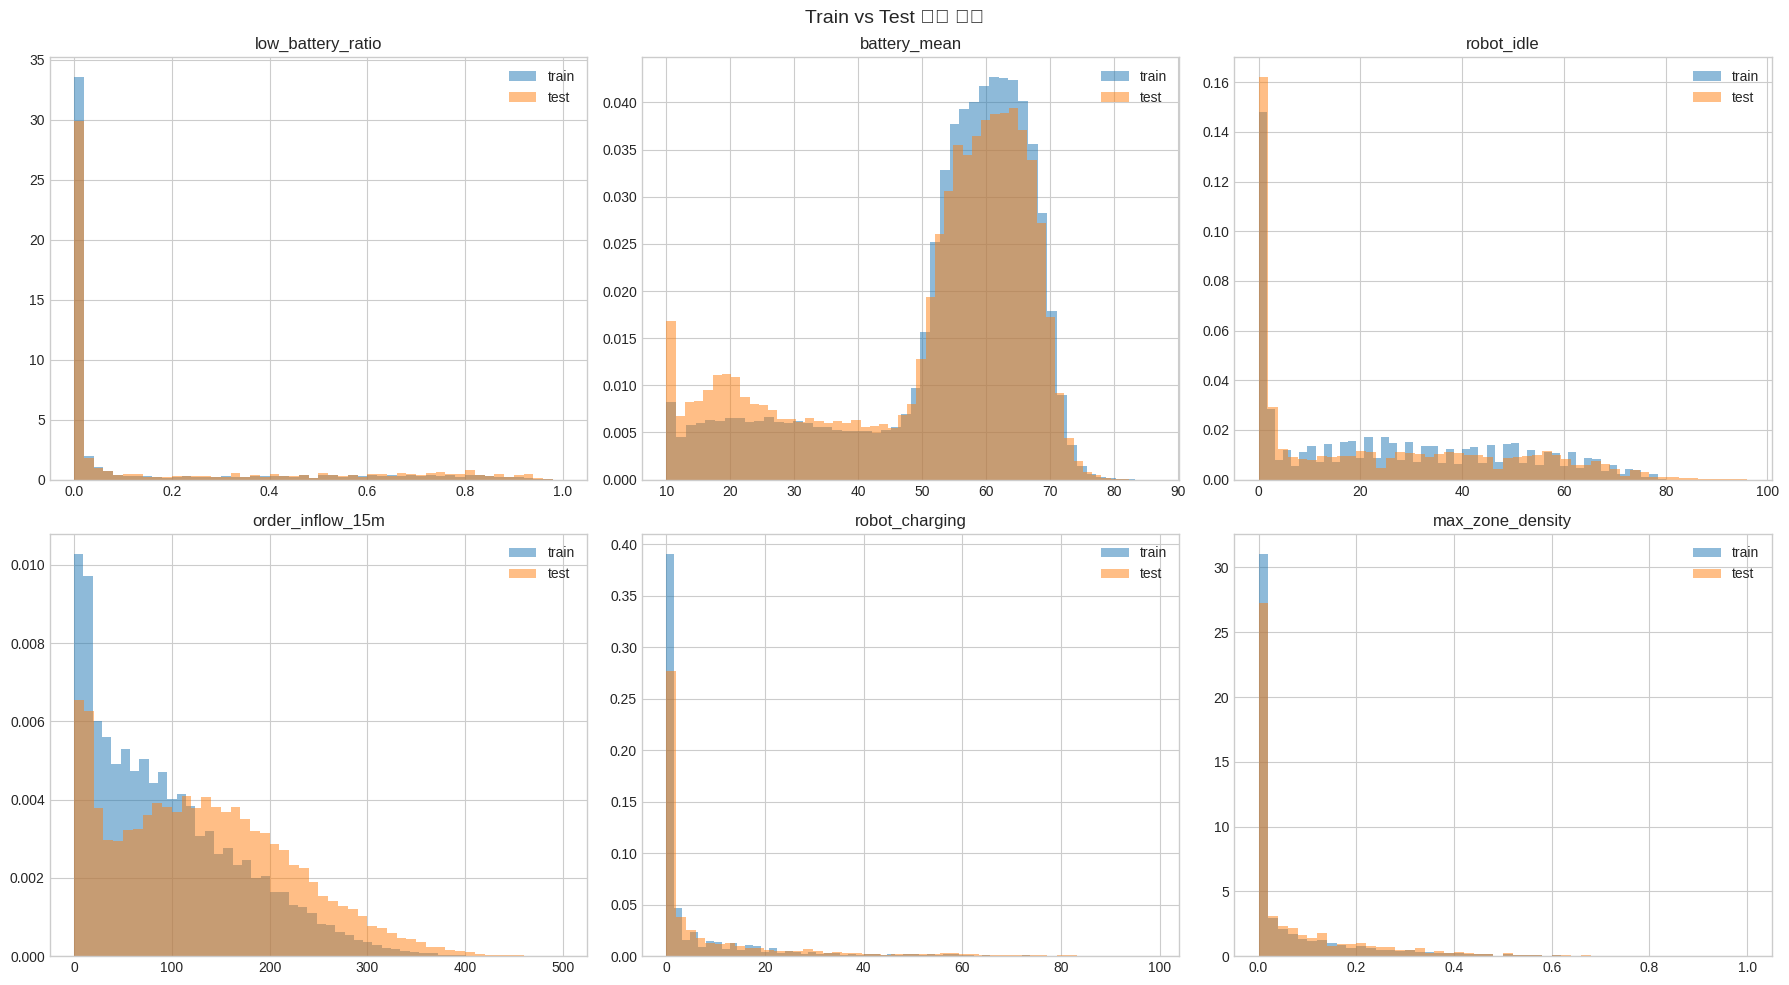

In [16]:
# 주요 피처의 train/test 분포 비교
compare_cols = corr_with_target.head(6).index.tolist() if 'corr_with_target' in dir() else num_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, col in enumerate(compare_cols):
    row, col_idx = idx // 3, idx % 3
    axes[row][col_idx].hist(train[col], bins=50, alpha=0.5, label='train', density=True)
    axes[row][col_idx].hist(test[col], bins=50, alpha=0.5, label='test', density=True)
    axes[row][col_idx].set_title(col)
    axes[row][col_idx].legend()

plt.suptitle('Train vs Test 분포 비교', fontsize=14)
plt.tight_layout()
plt.show()

## 9. ✅ EDA 요약 및 피처 엔지니어링 방향

### 타겟 분포
- 평균 **18.96분**, 중앙값 **9.03분** → 강한 우편향 (skewness 5.68)
- `log1p` 변환 후 skewness **0.08** → **로그 변환 04.08에 실험**
- 이상치: 최대 715분, 상위 1%는 120분 이상 → cap 실험 예정

### 결측치
- 40개+ 컬럼에 약 **12% 균등 결측** (MCAR 패턴)
- 타임슬롯별로 고르게 분포 → LightGBM 내장 처리로 충분
- 별도 imputation 실험은 Week 2에 옵션으로 검토

### 핵심 피처 (상관계수 기준)
| 순위 | 피처 | |r|| 도메인 의미 |
|---|---|---|---|
| 1 | low_battery_ratio | 0.366 | 배터리 부족 로봇 비율 |
| 2 | battery_mean | 0.359 | 평균 배터리 잔량 (낮을수록 지연) |
| 3 | robot_idle | 0.349 | 유휴 로봇 수 (주문 소화 실패) |
| 4 | order_inflow_15m | 0.342 | 15분 주문 유입량 |
| 5 | robot_charging | 0.320 | 충전 중인 로봇 수 |

### 시간 패턴 (핵심!)
- ts=0: 11.3분 → ts=24: 21.9분 (1.9배 증가)
- **`ts_idx`, `ts_ratio`, `ts_sin/cos`** 피처 04.09에 추가

### layout 보조 테이블
- hub_spoke 레이아웃 평균 지연 22.3분 (grid 18.1분 대비 +4.2분)
- `layout_type` LightGBM 범주형으로 처리 → 자동 활용

### Week 2 피처 엔지니어링 우선순위
1. **Lag 피처** (lag1~3): 직전 타임슬롯의 배터리/혼잡도 상태
2. **Rolling 피처** (roll3, roll5): 최근 추세 포착
3. **배터리 복합 피처**: `low_battery_ratio × charge_queue_length`
4. **주문 압박 지수**: `order_inflow_15m × urgent_order_ratio`